In [1]:
import numpy as np
from rpforest import RPForest
from scipy.io import loadmat
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
def get_mf_dino2():
    data = np.zeros((0, 384), dtype=np.float32)

    # Load Dino2
    for i in range(100):
        fp = loadmat(f"/Volumes/Data/mf_dino2/{i}.mat")['features']
        fp /= np.linalg.norm(fp, axis=1, keepdims=True)
        data = np.vstack((data, fp))
        
    data = np.ascontiguousarray(data, dtype=np.float32)
    return data

data = get_mf_dino2()

In [3]:
print(data.shape)

(1000000, 384)


In [4]:
x = RPForest(leaf_size=1000, no_trees=10)
x.fit(data)

In [5]:
xx = 0

for i in x.get_leaf_nodes():
    print(i)
    
    xx += 1
    
    if xx == 10:
        break

('0:0000000000', [1212, 4629, 5938, 6153, 6886, 7032, 7487, 10627, 12533, 12700, 13103, 13886, 14809, 16506, 16676, 17510, 18745, 19054, 20710, 20811, 20967, 21284, 21294, 21468, 21476, 25668, 26187, 26717, 28646, 28999, 29086, 29899, 30139, 30171, 30442, 30446, 31975, 33577, 35042, 36463, 36533, 38103, 38265, 38304, 38661, 40353, 41821, 43624, 45487, 48600, 48707, 49696, 49740, 50090, 51322, 52357, 55043, 55468, 55815, 55957, 56598, 58431, 58557, 60235, 60539, 61010, 62330, 65264, 68504, 68825, 70599, 74816, 75638, 76591, 77610, 78248, 80811, 82679, 83852, 83909, 84467, 84695, 85872, 87719, 87879, 89177, 89471, 89564, 90839, 90958, 91140, 92164, 92944, 94308, 94531, 96261, 98971, 99246, 99465, 101956, 102729, 103354, 104023, 104612, 105802, 105825, 105983, 106040, 106303, 106472, 108034, 108405, 109022, 109876, 112427, 112812, 113408, 114489, 114658, 115098, 115942, 117359, 118161, 121264, 122947, 124014, 125075, 125604, 127223, 127999, 128032, 128194, 130175, 131239, 131892, 132140, 

In [6]:
j = 0

results = [[] for i in range(1_000_000)]

for leaf in tqdm(x.get_leaf_nodes()):
    
    ids = np.array(leaf[1])
    
    dot_prods = data[ids] @ data[ids].T    
    sorted_idxs = np.flip(np.argsort(dot_prods, axis=1), axis=1)
    
    indexes = sorted_idxs[:, 0]
    top_k = sorted_idxs[:, 1:16]
        
    global_indexes = ids[indexes]        
    global_nns = ids[top_k]
    
    # Need to put the top k in each index, but convert back to global IDs
    for i in range(len(indexes)):
        results[global_indexes[i]].extend(global_nns[i])

10240it [08:59, 19.00it/s]


In [7]:
for i in range(1_000_000):
    results[i] = list(set(results[i]))

In [8]:
print(results[0])

[79363, 843278, 338448, 1040, 24594, 244248, 949273, 680476, 13861, 787494, 709673, 675881, 683569, 661553, 595002, 569403, 649789, 601679, 647763, 559191, 935515, 957022, 732255, 477278, 902242, 719972, 477802, 952427, 497258, 913010, 87671, 841851, 93821, 504459, 734347, 778892, 385165, 367761, 931988, 510612, 188566, 154, 271003, 179868, 184991, 834211, 860840, 516787, 520887, 868538, 571588, 210117, 133836, 472780, 633040, 580820, 522453, 5339, 756451, 852710, 137447, 456430, 700143, 13556, 447734, 633594, 827645, 50949, 578823, 325896, 428809, 633104, 528144, 631056, 284948, 374047, 446242, 573224, 458026, 560428, 379180, 573742, 529203, 918835, 547639, 963895, 597303, 121146, 917309, 819008, 727876, 626505, 140112, 198994, 384855, 759644, 444777, 842090, 781163, 888171, 239466, 585585, 551281, 430965, 644470, 467319, 977283, 104324, 93061, 541066, 811918, 940942, 698257, 844695, 87960, 186265, 905116, 339359, 744864, 129446, 424874, 747440, 138683, 192446, 574912, 208839, 386505,

In [9]:
dists = [[] for i in range(1_000_000)]

for id in tqdm(range(len(dists))):
    nns = results[id]
    
    for nn in nns:
        dot_prod = np.dot(data[id], data[nn])
        dists[id].append(dot_prod)


100%|██████████| 1000000/1000000 [03:16<00:00, 5078.71it/s]


In [10]:
argsorted_dist_rows = [np.flip(np.argsort(x)) for x in dists]
print(argsorted_dist_rows[0])

[101  85  38  34 126  96  15  77  20 112  11 129  95  91  12 133  24  36
 136  13  90  27  86 132   2  47 122  68  53 109  94  22  49  74 135  89
  82  58 130  64  19  43   6   9  17  84 134 117  87  44  51  42  46  79
 111  78  59  97  10  33 100   5  14  40 105  21 121  48  62  52  45 102
  32  65  23  81  66  93  50 107   3  25   1  99  88  61 118  98  71   7
  67 108 131  80 138 140   0  28  75  56  30  35  92 114 103  60 113 120
 110 139  83  26  72 137  31  76   8 104  37  55  41 128  57  54 124  63
   4 106 119  70  18 123  39  29 127 125  69 115  16 116  73]


In [11]:
nn15_seed = [[] for i in range(1_000_000)]

for i in tqdm(range(len(results))):
    nn15_seed[i] = np.array(results[i])[argsorted_dist_rows[i][:15]]

100%|██████████| 1000000/1000000 [00:07<00:00, 132220.86it/s]


In [12]:
len_overlaps = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:16]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps.append(len(overlap))

Text(0, 0.5, 'Frequency')

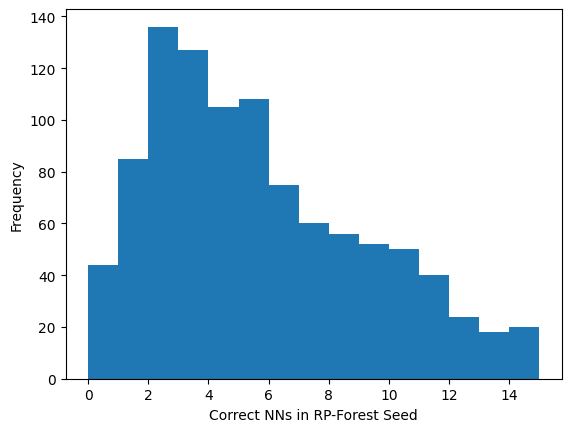

In [13]:
plt.hist(len_overlaps, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed")
plt.ylabel("Frequency")

In [ ]:
print(np.mean(len_overlaps) / 15)


0.3489333333333333


In [15]:
# 15 @ 100
len_overlaps_at_100 = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:101]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps_at_100.append(len(overlap))
    

Text(0, 0.5, 'Frequency')

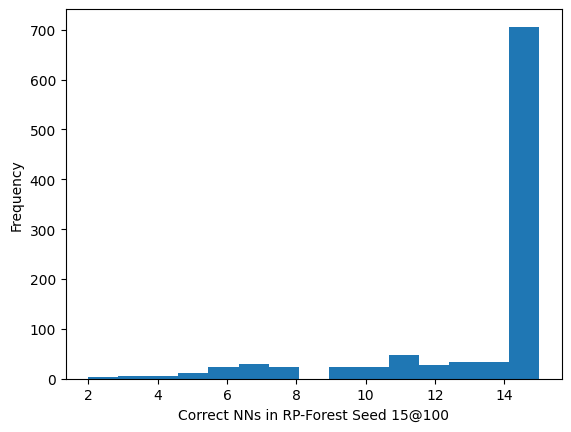

In [16]:
plt.hist(len_overlaps_at_100, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed 15@100")
plt.ylabel("Frequency")

In [ ]:
print(np.mean(len_overlaps_at_100) / 15)
